# Topology, Density, and C--C Topology Results

Loads CREAM results for full-DAG topology, full-DAG density, and C--C fixed-count topology experiments. Each section includes original CREAM as a reference row/curve when available.


In [3]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_colwidth', 180)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'experiments').exists() and (PROJECT_ROOT.parent / 'experiments').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASETS = {
    'celeba': {
        'display': 'CelebA',
        'model': 'Standard_CelebA',
        'original_experiment': 'CREAM_best_celeba',
    },
    'cub': {
        'display': 'CUB',
        'model': 'Standard_CUB',
        'original_experiment': 'CREAM_cub/seed_0',
    },
    'cfmnist': {
        'display': 'Complete_Concept_FMNIST',
        'model': 'Standard_FashionMNIST',
        'original_experiment': 'CREAM_best_cfmnist',
    },
}

FAMILIES = {
    'topology_random_full': 'Full-DAG topology random, fixed full-DAG edge count',
    'density_random_full': 'Full-DAG density random, varied full-DAG edge count',
    'concept_concept_fixcount_topology': 'C--C-only topology replacement, fixed C--C edge count',
}

KEY_METRICS = [
    'dataset', 'family', 'variant', 'is_original_reference',
    'test_task_accuracy', 'test_concept_accuracy', 'CCI',
    'PFI_concept_importance', 'PFI_side_importance', 'concept_leakage',
    'c2y_baseline_accuracy', 'test_dropout_task_accuracy',
    'metrics_path',
]


def experiment_root(dataset, family):
    meta = DATASETS[dataset]
    return (
        PROJECT_ROOT / 'experiments' / meta['display'] / 'train_cbm' / meta['model'] /
        f'{dataset}_{family}' / f'CREAM_{dataset}_{family}'
    )


def original_root(dataset):
    meta = DATASETS[dataset]
    return (
        PROJECT_ROOT / 'experiments' / meta['display'] / 'train_cbm' / meta['model'] /
        'CREAM' / meta['original_experiment']
    )


def read_metric_row(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        print(f'Skipping unreadable metrics CSV {csv_path}: {exc}')
        return None
    if df.empty:
        return None
    return df.iloc[0].to_dict()


def choose_metric_csv(root):
    candidates = sorted((root / 'last_metrics').glob('*.csv'))
    candidates += sorted(root.glob('**/last_metrics/*.csv'))
    # Do not scan arbitrary root CSVs here; intermediate activation CSVs can be large.
    seen = set()
    deduped = []
    for path in candidates:
        key = str(path.resolve()) if path.exists() else str(path)
        if key not in seen:
            deduped.append(path)
            seen.add(key)
    return deduped[-1] if deduped else None


def load_result_metrics():
    rows = []
    for dataset in DATASETS:
        # Original CREAM reference once per family, so every section can display it.
        o_root = original_root(dataset)
        o_csv = choose_metric_csv(o_root)
        if o_csv is not None:
            row = read_metric_row(o_csv)
            if row is not None:
                for family in FAMILIES:
                    copied = dict(row)
                    copied.update({
                        'dataset': dataset,
                        'family': family,
                        'variant': 'original_CREAM',
                        'is_original_reference': True,
                        'metrics_path': str(o_csv),
                    })
                    rows.append(copied)
        else:
            print(f'Original CREAM metrics not found for {dataset}: {o_root}')

        for family in FAMILIES:
            root = experiment_root(dataset, family)
            if not root.exists():
                print(f'Result root not found yet for {dataset}/{family}: {root}')
                continue
            for variant_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
                csv_path = choose_metric_csv(variant_dir)
                if csv_path is None:
                    continue
                row = read_metric_row(csv_path)
                if row is None:
                    continue
                row.update({
                    'dataset': dataset,
                    'family': family,
                    'variant': variant_dir.name,
                    'is_original_reference': False,
                    'metrics_path': str(csv_path),
                })
                rows.append(row)
    return pd.DataFrame(rows)


def intervention_accuracy_column(df):
    for col in ['test_task_accuracy', 'task_accuracy', 'accuracy', 'test_accuracy', 'test_acc']:
        if col in df.columns:
            return col
    matches = [col for col in df.columns if 'accuracy' in col.lower() or col.lower().endswith('_acc')]
    return matches[0] if matches else None


def choose_intervention_csv(root):
    candidates = sorted(root.glob('lightning_logs/**/intervention_results.csv'))
    candidates += sorted(root.glob('**/intervention_results.csv'))
    seen = set()
    deduped = []
    for path in candidates:
        key = str(path.resolve()) if path.exists() else str(path)
        if key not in seen:
            deduped.append(path)
            seen.add(key)
    return deduped[-1] if deduped else None


def load_result_interventions():
    rows = []
    for dataset in DATASETS:
        o_root = original_root(dataset)
        o_csv = choose_intervention_csv(o_root)
        if o_csv is not None:
            df = pd.read_csv(o_csv)
            if not df.empty:
                for family in FAMILIES:
                    copied = df.copy()
                    copied['dataset'] = dataset
                    copied['family'] = family
                    copied['variant'] = 'original_CREAM'
                    copied['is_original_reference'] = True
                    copied['intervention_path'] = str(o_csv)
                    rows.append(copied)
        else:
            print(f'Original CREAM intervention curve not found for {dataset}: {o_root}')

        for family in FAMILIES:
            root = experiment_root(dataset, family)
            if not root.exists():
                continue
            for variant_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
                csv_path = choose_intervention_csv(variant_dir)
                if csv_path is None:
                    continue
                df = pd.read_csv(csv_path)
                if df.empty:
                    continue
                df['dataset'] = dataset
                df['family'] = family
                df['variant'] = variant_dir.name
                df['is_original_reference'] = False
                df['intervention_path'] = str(csv_path)
                rows.append(df)
    return pd.concat(rows, ignore_index=True, sort=False) if rows else pd.DataFrame()


def available(columns, requested):
    return [col for col in requested if col in columns]


def display_family_results(family, metrics_df, interventions_df):
    print(f"\n=== {family}: {FAMILIES[family]} ===")
    fam_metrics = metrics_df[metrics_df['family'] == family].copy() if not metrics_df.empty else pd.DataFrame()
    if fam_metrics.empty:
        print('No metrics found yet for this family.')
    else:
        cols = available(fam_metrics.columns, KEY_METRICS)
        sort_cols = available(fam_metrics.columns, ['dataset', 'is_original_reference', 'variant'])
        table = fam_metrics[cols].sort_values(sort_cols, ascending=[True, False, True] if len(sort_cols) == 3 else True)
        display(table)

    fam_interventions = interventions_df[interventions_df['family'] == family].copy() if not interventions_df.empty else pd.DataFrame()
    if fam_interventions.empty:
        print('No intervention curves found yet for this family.')
        return
    acc_col = intervention_accuracy_column(fam_interventions)
    if acc_col is None or 'num_interventions' not in fam_interventions.columns:
        print('Intervention CSVs found, but no plottable accuracy/num_interventions columns.')
        display(fam_interventions.head())
        return

    for dataset, dataset_df in fam_interventions.groupby('dataset'):
        group_values = [None]
        if 'group_interventions' in dataset_df.columns:
            group_values = sorted(dataset_df['group_interventions'].dropna().unique())
        for group_value in group_values:
            df = dataset_df if group_value is None else dataset_df[dataset_df['group_interventions'] == group_value]
            if df.empty:
                continue
            fig, ax = plt.subplots(figsize=(8.5, 5))
            for variant, variant_df in df.groupby('variant'):
                variant_df = variant_df.dropna(subset=['num_interventions', acc_col]).sort_values('num_interventions')
                if variant_df.empty:
                    continue
                is_original = bool(variant_df['is_original_reference'].iloc[0]) if 'is_original_reference' in variant_df.columns else False
                linewidth = 3.0 if is_original else 1.8
                linestyle = '--' if is_original else '-'
                ax.plot(
                    variant_df['num_interventions'],
                    variant_df[acc_col],
                    marker='o',
                    linewidth=linewidth,
                    linestyle=linestyle,
                    label=variant,
                )
            suffix = '' if group_value is None else f' | group_interventions={group_value}'
            ax.set_title(f'{dataset}: {family} intervention curve{suffix}')
            ax.set_xlabel('Number of interventions')
            ax.set_ylabel(acc_col)
            ax.grid(True, alpha=0.3)
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.tight_layout()
            plt.show()


## Load Results


In [4]:
metrics = load_result_metrics()
interventions = load_result_interventions()

print(f'Loaded metric rows: {len(metrics)}')
print(f'Loaded intervention rows: {len(interventions)}')

if not metrics.empty:
    metrics_out = PROJECT_ROOT / 'notebook/topology_density_c2c_results_metrics.csv'
    metrics.to_csv(metrics_out, index=False)
    print(f'Saved metrics table to {metrics_out}')

if not interventions.empty:
    interventions_out = PROJECT_ROOT / 'notebook/topology_density_c2c_results_interventions.csv'
    interventions.to_csv(interventions_out, index=False)
    print(f'Saved intervention table to {interventions_out}')


Loaded metric rows: 52
Loaded intervention rows: 2918
Saved metrics table to /home/dani00003/mCREAM/notebook/topology_density_c2c_results_metrics.csv
Saved intervention table to /home/dani00003/mCREAM/notebook/topology_density_c2c_results_interventions.csv


## All Result Metrics


In [5]:
if metrics.empty:
    print('No metrics found yet. Run the Condor jobs first, then rerun this notebook.')
else:
    cols = available(metrics.columns, KEY_METRICS)
    display(metrics[cols].sort_values(['family', 'dataset', 'is_original_reference', 'variant'], ascending=[True, True, False, True]))


,dataset,family,variant,is_original_reference,test_task_accuracy,test_concept_accuracy,CCI,PFI_concept_importance,PFI_side_importance,test_dropout_task_accuracy,metrics_path
2,celeba,concept_concept_fixcount_topology,original_CREAM,True,0.816251,0.810454,1.000000,0.316497,-1.597459e-08,0.816350,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/CREAM/CREAM_best_celeba/last_metrics/CREAM_celeba_graph_sanity_original.csv
12,celeba,concept_concept_fixcount_topology,replace_000,False,0.816251,0.810454,1.000000,0.316497,-1.597459e-08,0.816350,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_000/last_met...
13,celeba,concept_concept_fixcount_topology,replace_020,False,0.824166,0.799920,1.000000,0.324516,2.504578e-08,0.823962,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_020/last_met...
14,celeba,concept_concept_fixcount_topology,replace_080,False,0.802725,0.802196,1.000000,0.302951,1.804681e-08,0.802700,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_080/last_met...
15,celeba,concept_concept_fixcount_topology,replace_100,False,0.827673,0.808565,1.000000,0.327847,2.284815e-08,0.827717,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_100/last_met...
36,cfmnist,concept_concept_fixcount_topology,original_CREAM,True,0.924300,0.980918,0.957057,0.716062,2.077701e-02,0.923851,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/CREAM/CREAM_best_cfmnist/last_metrics/CREAM_best_cfmnist_soft_config.csv
47,cfmnist,concept_concept_fixcount_topology,replace_000,False,0.923100,0.980582,0.931452,0.700221,3.561099e-02,0.922619,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...
48,cfmnist,concept_concept_fixcount_topology,replace_020,False,0.924100,0.980773,0.956146,0.712031,1.953598e-02,0.923645,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...
49,cfmnist,concept_concept_fixcount_topology,replace_050,False,0.924700,0.981054,0.950747,0.713406,2.210002e-02,0.923851,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...
50,cfmnist,concept_concept_fixcount_topology,replace_080,False,0.923900,0.981246,0.961365,0.718640,1.452301e-02,0.922927,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...


## Full-DAG Topology

Family key: `topology_random_full`



=== topology_random_full: Full-DAG topology random, fixed full-DAG edge count ===


,dataset,family,variant,is_original_reference,test_task_accuracy,test_concept_accuracy,CCI,PFI_concept_importance,PFI_side_importance,test_dropout_task_accuracy,metrics_path
0,celeba,topology_random_full,original_CREAM,True,0.816251,0.810454,1.000000,0.316497,-1.597459e-08,0.816350,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/CREAM/CREAM_best_celeba/last_metrics/CREAM_celeba_graph_sanity_original.csv
3,celeba,topology_random_full,rand_topology_01,False,0.809889,0.810826,1.000000,0.309831,-8.581492e-09,0.809753,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_topology_random_full/CREAM_celeba_topology_random_full/rand_topology_01/last_metrics/CREAM_celeba_top...
4,celeba,topology_random_full,rand_topology_02,False,0.788348,0.821647,1.000000,0.288841,-2.062663e-08,0.788339,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_topology_random_full/CREAM_celeba_topology_random_full/rand_topology_02/last_metrics/CREAM_celeba_top...
5,celeba,topology_random_full,rand_topology_03,False,0.804178,0.796585,1.000000,0.304404,1.809458e-09,0.804171,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_topology_random_full/CREAM_celeba_topology_random_full/rand_topology_03/last_metrics/CREAM_celeba_top...
6,celeba,topology_random_full,rand_topology_04,False,0.826921,0.796263,1.000000,0.327109,1.480412e-08,0.826804,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_topology_random_full/CREAM_celeba_topology_random_full/rand_topology_04/last_metrics/CREAM_celeba_top...
34,cfmnist,topology_random_full,original_CREAM,True,0.924300,0.980918,0.957057,0.716062,2.077701e-02,0.923851,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/CREAM/CREAM_best_cfmnist/last_metrics/CREAM_best_cfmnist_soft_config.csv
37,cfmnist,topology_random_full,rand_topology_00,False,0.837800,0.893727,0.283935,0.482846,3.939720e-01,0.568760,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_topology_random_full/CREAM_cfmnist_topology_random_full/rand_topology_00/last...
38,cfmnist,topology_random_full,rand_topology_01,False,0.918900,0.874918,0.522876,0.602536,4.547360e-01,0.816297,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_topology_random_full/CREAM_cfmnist_topology_random_full/rand_topology_01/last...
39,cfmnist,topology_random_full,rand_topology_02,False,0.834700,0.906127,0.404421,0.610233,2.744460e-01,0.652915,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_topology_random_full/CREAM_cfmnist_topology_random_full/rand_topology_02/last...
40,cfmnist,topology_random_full,rand_topology_03,False,0.642200,0.943800,0.409357,0.322942,3.592280e-01,0.460283,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_topology_random_full/CREAM_cfmnist_topology_random_full/rand_topology_03/last...


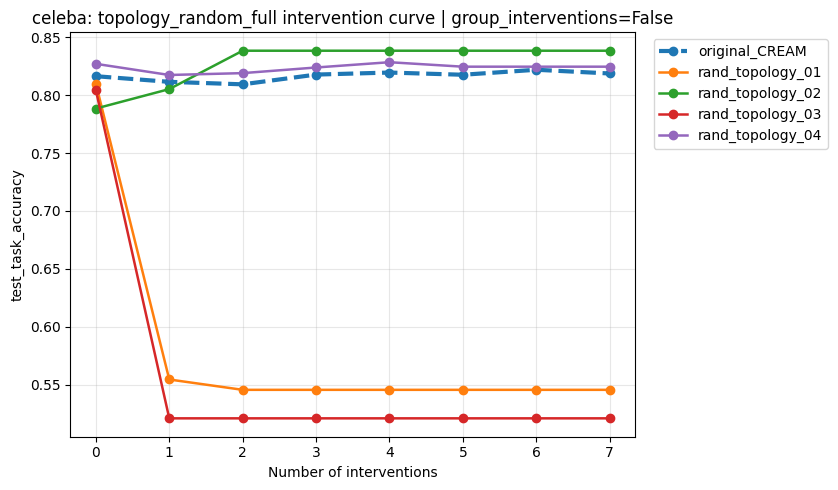

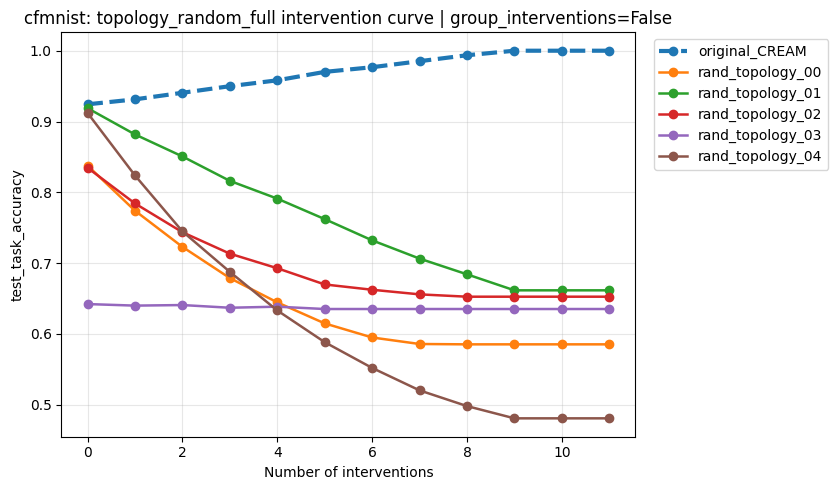

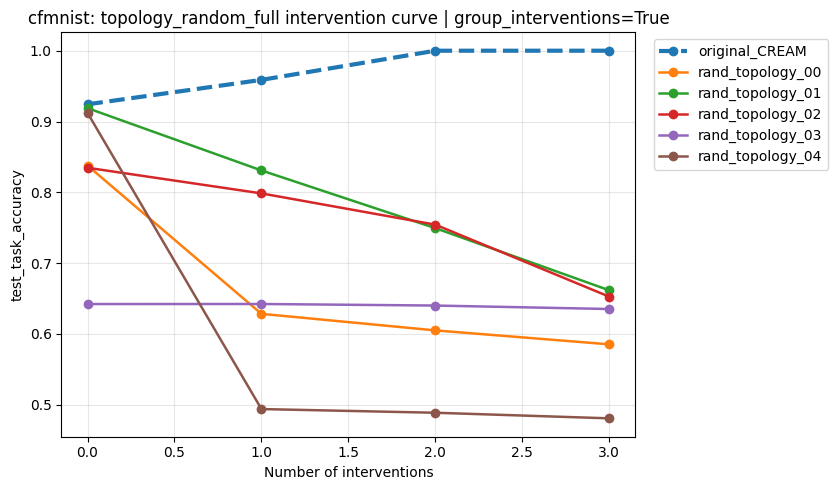

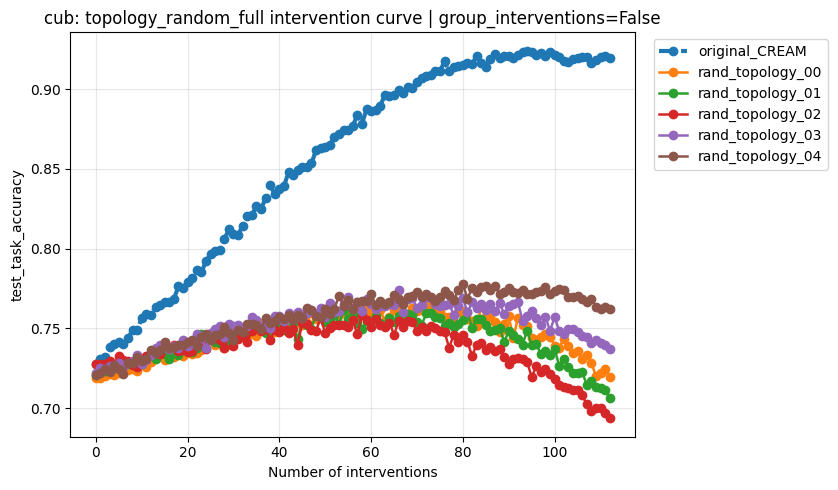

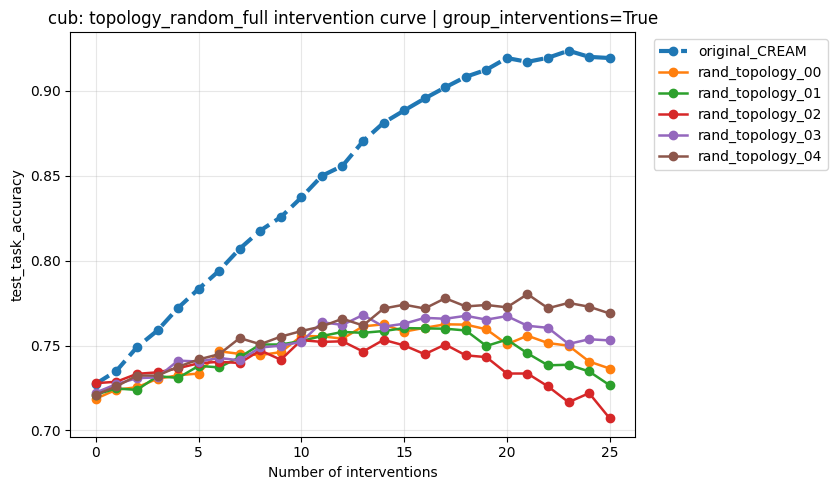

In [6]:
display_family_results('topology_random_full', metrics, interventions)


## Full-DAG Density

Family key: `density_random_full`



=== density_random_full: Full-DAG density random, varied full-DAG edge count ===


,dataset,family,variant,is_original_reference,test_task_accuracy,test_concept_accuracy,CCI,PFI_concept_importance,PFI_side_importance,test_dropout_task_accuracy,metrics_path
1,celeba,density_random_full,original_CREAM,True,0.816251,0.810454,1.000000,0.316497,-1.597459e-08,0.816350,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/CREAM/CREAM_best_celeba/last_metrics/CREAM_celeba_graph_sanity_original.csv
7,celeba,density_random_full,edges_00009,False,0.797415,0.785822,1.000000,0.297887,-1.098216e-08,0.797371,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_density_random_full/CREAM_celeba_density_random_full/edges_00009/last_metrics/CREAM_celeba_density_ra...
8,celeba,density_random_full,edges_00014,False,0.822813,0.797637,1.000000,0.323004,-1.327534e-08,0.822795,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_density_random_full/CREAM_celeba_density_random_full/edges_00014/last_metrics/CREAM_celeba_density_ra...
9,celeba,density_random_full,edges_00018,False,0.763601,0.810075,1.000000,0.263737,-1.533561e-08,0.763473,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_density_random_full/CREAM_celeba_density_random_full/edges_00018/last_metrics/CREAM_celeba_density_ra...
10,celeba,density_random_full,edges_00022,False,0.817203,0.810454,1.000000,0.317500,2.161796e-09,0.817162,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_density_random_full/CREAM_celeba_density_random_full/edges_00022/last_metrics/CREAM_celeba_density_ra...
11,celeba,density_random_full,edges_00027,False,0.806532,0.809703,1.000000,0.307169,-2.861692e-08,0.806556,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_density_random_full/CREAM_celeba_density_random_full/edges_00027/last_metrics/CREAM_celeba_density_ra...
35,cfmnist,density_random_full,original_CREAM,True,0.924300,0.980918,0.957057,0.716062,2.077701e-02,0.923851,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/CREAM/CREAM_best_cfmnist/last_metrics/CREAM_best_cfmnist_soft_config.csv
42,cfmnist,density_random_full,edges_00023,False,0.639100,0.797273,0.210709,0.484221,1.986470e-01,0.545772,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_density_random_full/CREAM_cfmnist_density_random_full/edges_00023/last_metric...
43,cfmnist,density_random_full,edges_00034,False,0.817700,0.816682,-3.028305,0.523102,3.766650e-01,0.455768,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_density_random_full/CREAM_cfmnist_density_random_full/edges_00034/last_metric...
44,cfmnist,density_random_full,edges_00046,False,0.924500,0.887309,-0.375871,0.596323,4.368470e-01,0.666461,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_density_random_full/CREAM_cfmnist_density_random_full/edges_00046/last_metric...


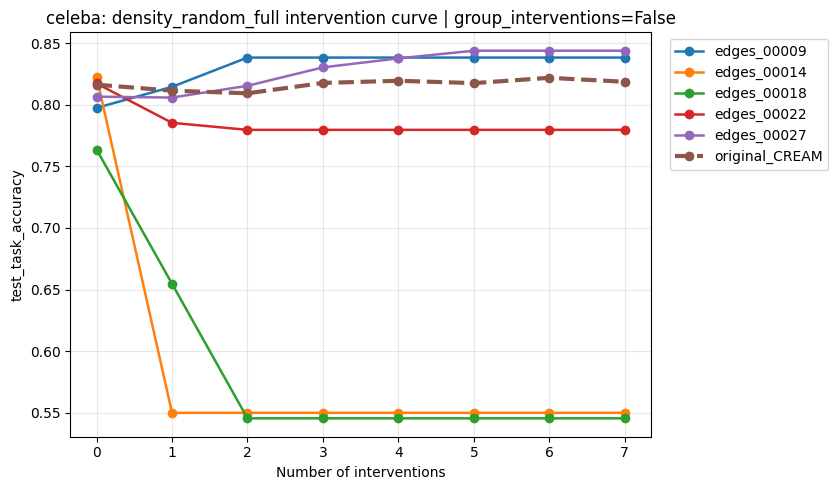

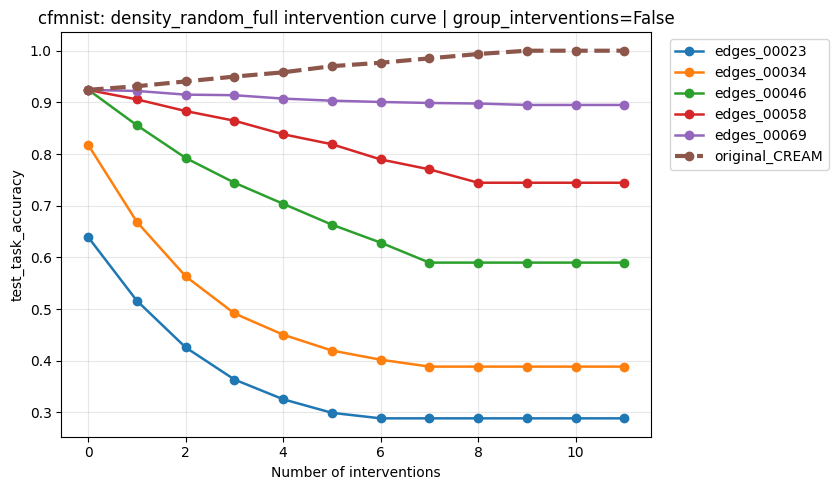

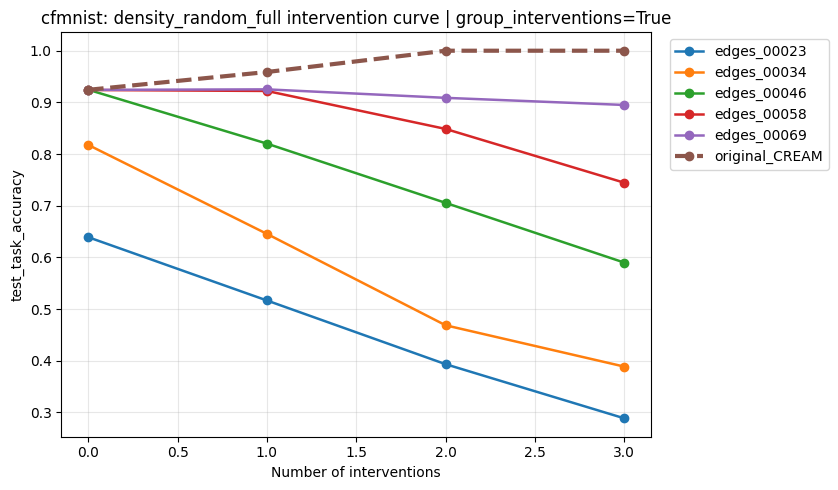

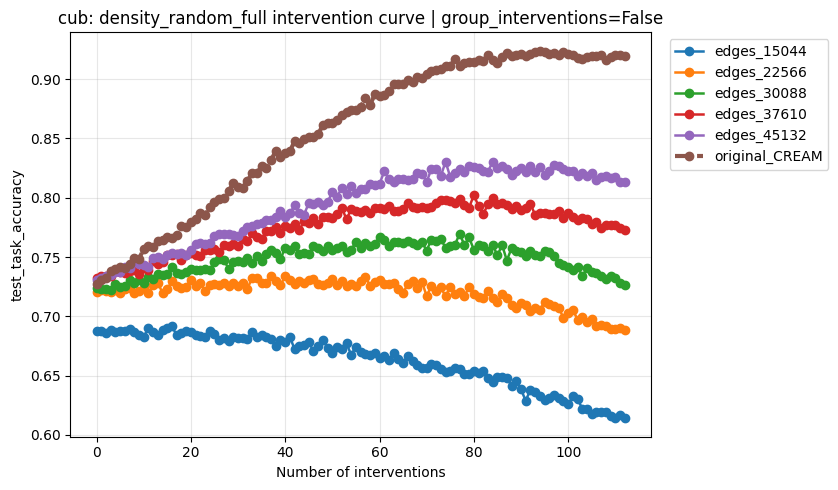

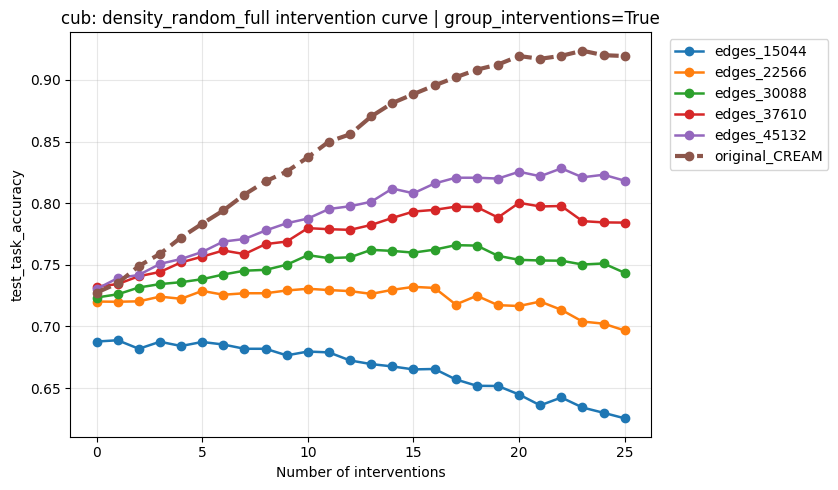

In [7]:
display_family_results('density_random_full', metrics, interventions)


## C--C Fixed-Count Topology

Family key: `concept_concept_fixcount_topology`



=== concept_concept_fixcount_topology: C--C-only topology replacement, fixed C--C edge count ===


,dataset,family,variant,is_original_reference,test_task_accuracy,test_concept_accuracy,CCI,PFI_concept_importance,PFI_side_importance,test_dropout_task_accuracy,metrics_path
2,celeba,concept_concept_fixcount_topology,original_CREAM,True,0.816251,0.810454,1.000000,0.316497,-1.597459e-08,0.816350,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/CREAM/CREAM_best_celeba/last_metrics/CREAM_celeba_graph_sanity_original.csv
12,celeba,concept_concept_fixcount_topology,replace_000,False,0.816251,0.810454,1.000000,0.316497,-1.597459e-08,0.816350,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_000/last_met...
13,celeba,concept_concept_fixcount_topology,replace_020,False,0.824166,0.799920,1.000000,0.324516,2.504578e-08,0.823962,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_020/last_met...
14,celeba,concept_concept_fixcount_topology,replace_080,False,0.802725,0.802196,1.000000,0.302951,1.804681e-08,0.802700,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_080/last_met...
15,celeba,concept_concept_fixcount_topology,replace_100,False,0.827673,0.808565,1.000000,0.327847,2.284815e-08,0.827717,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_concept_concept_fixcount_topology/CREAM_celeba_concept_concept_fixcount_topology/replace_100/last_met...
36,cfmnist,concept_concept_fixcount_topology,original_CREAM,True,0.924300,0.980918,0.957057,0.716062,2.077701e-02,0.923851,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/CREAM/CREAM_best_cfmnist/last_metrics/CREAM_best_cfmnist_soft_config.csv
47,cfmnist,concept_concept_fixcount_topology,replace_000,False,0.923100,0.980582,0.931452,0.700221,3.561099e-02,0.922619,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...
48,cfmnist,concept_concept_fixcount_topology,replace_020,False,0.924100,0.980773,0.956146,0.712031,1.953598e-02,0.923645,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...
49,cfmnist,concept_concept_fixcount_topology,replace_050,False,0.924700,0.981054,0.950747,0.713406,2.210002e-02,0.923851,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...
50,cfmnist,concept_concept_fixcount_topology,replace_080,False,0.923900,0.981246,0.961365,0.718640,1.452301e-02,0.922927,/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_concept_concept_fixcount_topology/CREAM_cfmnist_concept_concept_fixcount_topo...


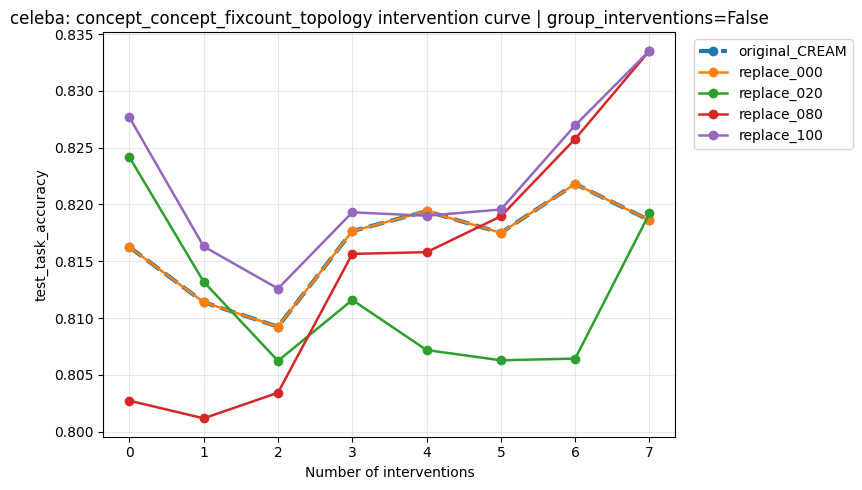

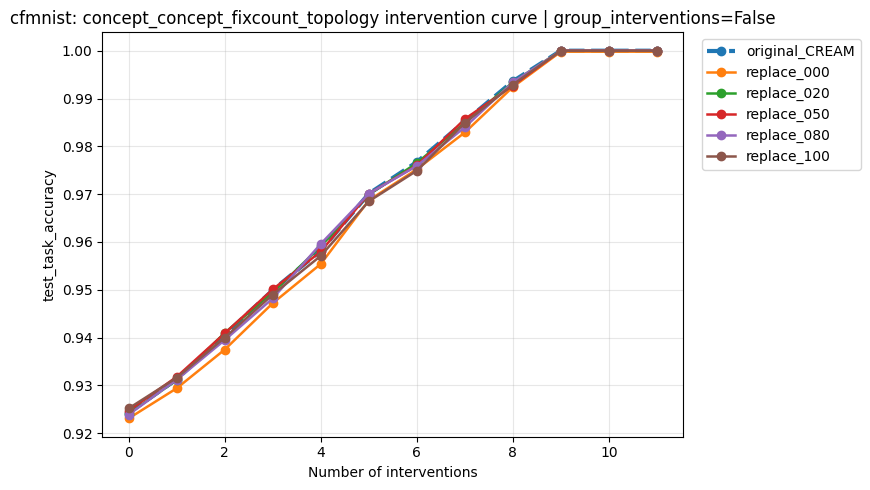

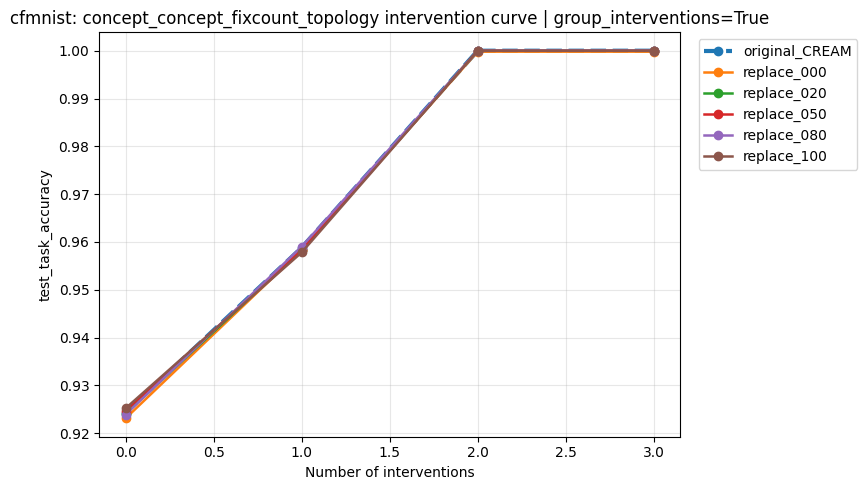

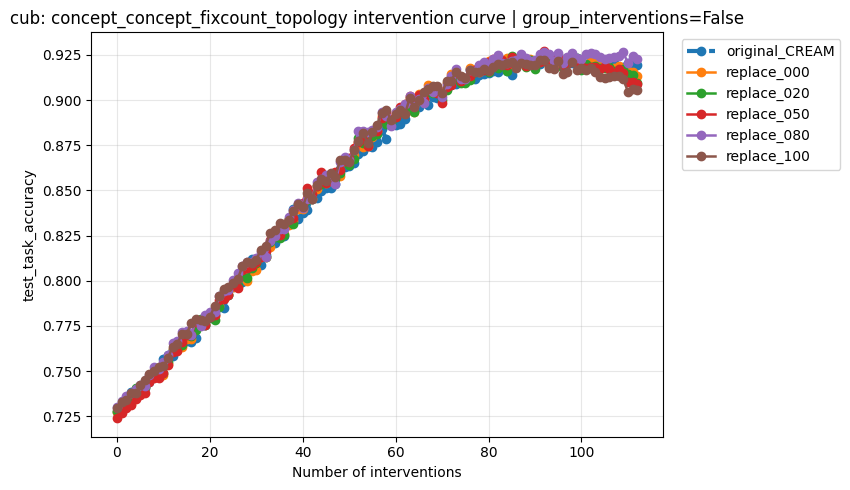

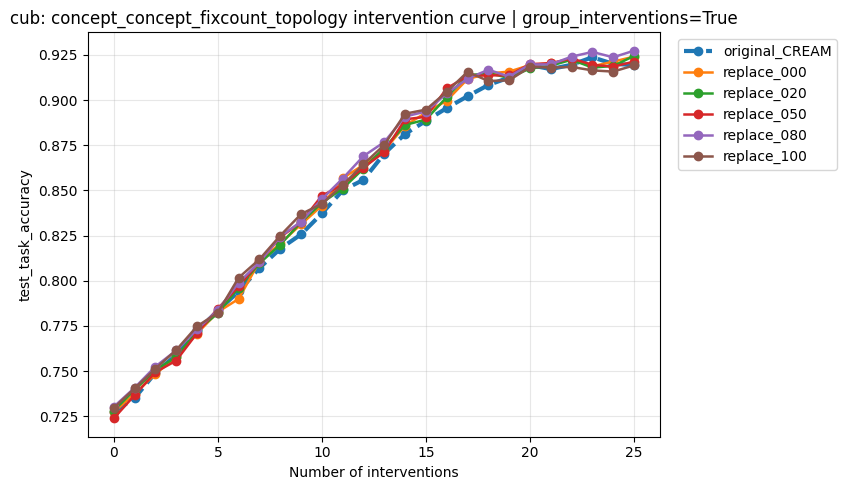

In [8]:
display_family_results('concept_concept_fixcount_topology', metrics, interventions)
